<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/percobaan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install opendatasets

In [11]:
import opendatasets as od

# Masukkan link URL dataset Kaggle langsung di sini
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Skipping, found downloaded files in "./brain-tumor-mri-data" (use force=True to force download)


In [12]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [13]:
data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in files:
            if class_counters[folder_aktif] >= 300:
                break
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:
                    # Sesuai template: cuma Grayscale (Resize & Equalization di tahap berikutnya)
                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")

Sukses membaca data mentah! Total data awal: 600 gambar.


In [14]:
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} gambar")
print(f"Total data: {len(data)} gambar")

Kelas glioma: 300 gambar
Kelas notumor: 300 gambar
Total data: 600 gambar


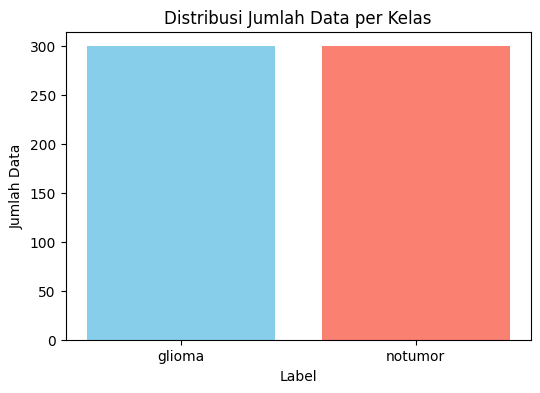

In [15]:
# Visualisasi distribusi data
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['skyblue','salmon'])
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.show()

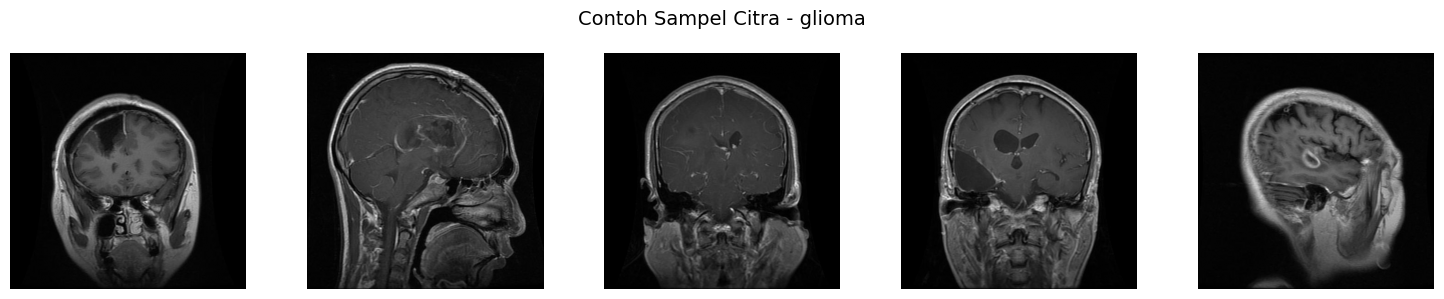

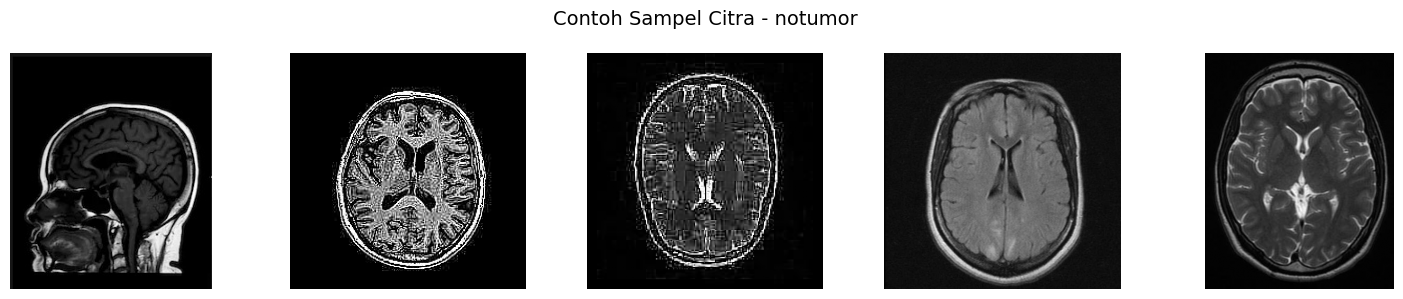

In [16]:
# Contoh sampel data tiap kelas
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f'Contoh Sampel Citra - {label}', fontsize=14)
    for k in range(5):
        axs[k].imshow(data[idxs[k]], cmap='gray')
        axs[k].axis('off')
    plt.tight_layout()
    plt.show()

In [39]:


def grayscale(image):
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def resize(image, target_size):
    return cv.resize(image, target_size)

def clahe_manual(citra, block_size=32, clip_limit=2.5):
    height, width = citra.shape
    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(0, height, block_size):
        for j in range(0, width, block_size):
            blok = citra[i:i+block_size, j:j+block_size]
            h_blok, w_blok = blok.shape

            hist = np.zeros(256, dtype=int)
            for bi in range(h_blok):
                for bj in range(w_blok):
                    hist[blok[bi][bj]] += 1

            total_piksel = h_blok * w_blok
            limit = int(clip_limit * total_piksel / 256)
            if limit < 1:
                limit = 1

            kelebihan = 0
            for c in range(256):
                if hist[c] > limit:
                    kelebihan += hist[c] - limit
                    hist[c] = limit

            distribusi_rata = kelebihan // 256
            sisa = kelebihan % 256

            for c in range(256):
                hist[c] += distribusi_rata
            for c in range(sisa):
                hist[c] += 1

            cdf = np.zeros(256, dtype=int)
            cdf[0] = hist[0]
            for c in range(1, 256):
                cdf[c] = cdf[c-1] + hist[c]

            cdf_min = cdf[cdf > 0][0] if len(cdf[cdf > 0]) > 0 else 0
            cdf_normal = np.zeros(256, dtype=int)

            pembagi = total_piksel - cdf_min
            for c in range(256):
                if pembagi > 0:
                    val = np.round((cdf[c] - cdf_min) * 255 / pembagi)
                    cdf_normal[c] = int(max(0, min(255, val)))
                else:
                    cdf_normal[c] = 0

            for bi in range(h_blok):
                for bj in range(w_blok):
                    hasil[i+bi][j+bj] = cdf_normal[blok[bi][bj]]

    return hasil.astype(np.uint8)

def median_filter_manual(image, kernel_size=3):
    h, w = image.shape
    pad = kernel_size // 2
    img_padded = np.pad(image, pad, mode='reflect')
    img_out = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            region = img_padded[i:i+kernel_size, j:j+kernel_size]
            img_out[i, j] = np.median(region)

    return img_out

def thresholding_manual(image, thresh_value=125):
    img_thresh = np.zeros_like(image)
    img_thresh[image > thresh_value] = 255
    return img_thresh



Sedang mengeksekusi Preprocessing Percobaan 4 ...
--- Selesai! ---
Total citra hasil Percobaan 1: 600 gambar.


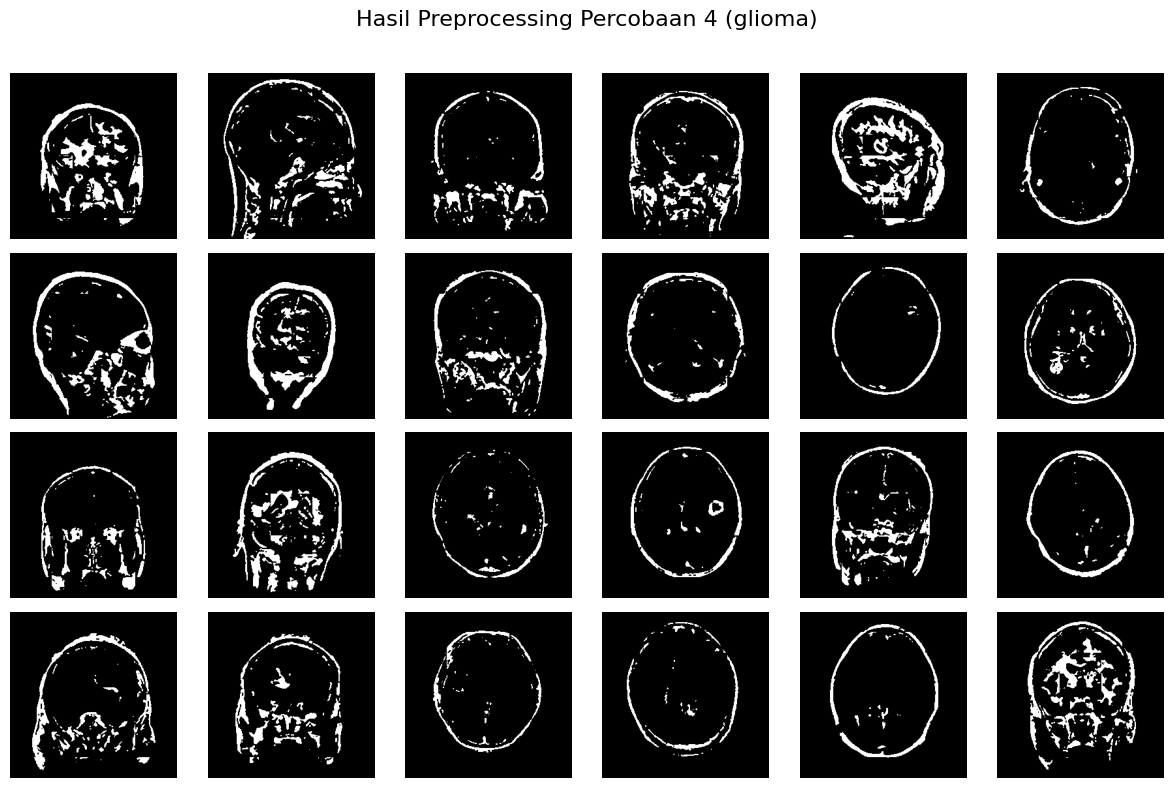

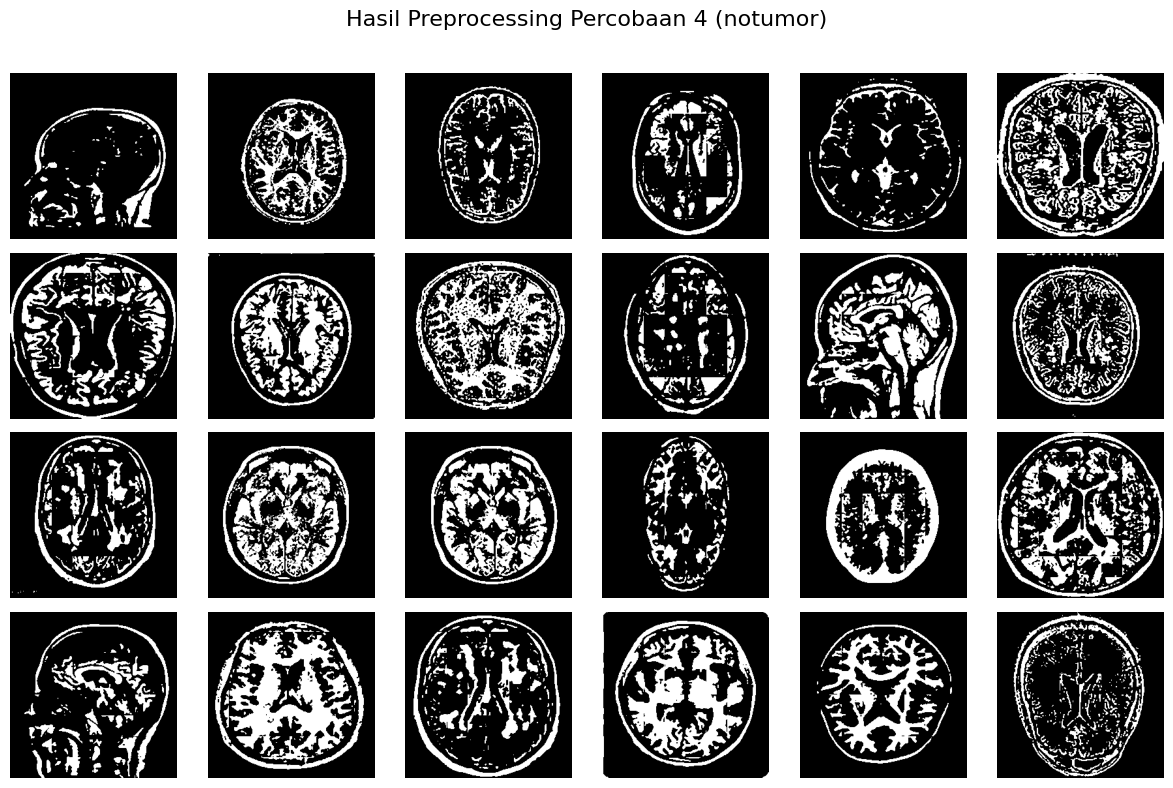

In [40]:
def percobaan4(image):
    img_gray = grayscale(image)
    img_resize = resize(img_gray, (256, 256))
    img_blur = median_filter_manual(img_resize, kernel_size=3)
    img_equalized = clahe_manual(img_blur, block_size=32, clip_limit=2.5)
    img_binary = thresholding_manual(img_equalized, thresh_value=155)
    return img_binary

dataPreprocessed = []

print("Sedang mengeksekusi Preprocessing Percobaan 4 ...")

for i in range(len(data)):
    img_hasil = percobaan4(data[i])
    dataPreprocessed.append(img_hasil)

dataPreprocessed = np.array(dataPreprocessed)

print("--- Selesai! ---")
print(f"Total citra hasil Percobaan 1: {len(dataPreprocessed)} gambar.")

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Hasil Preprocessing Percobaan 4 ({label})', fontsize=16)

    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]

        img_idx = idxs[k]
        ax.imshow(dataPreprocessed[img_idx], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [41]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

    return glcm

In [42]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [43]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0

        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan4')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,1958.320312,0.851628,0.876249,0.969884,7.679688,0.767812,0.476951,percobaan4
1,2516.132813,0.778768,0.887635,0.961306,9.867188,0.787896,0.459985,percobaan4
2,1589.765625,0.795939,0.925386,0.975552,6.234375,0.856339,0.334225,percobaan4
3,2324.882812,0.800362,0.886810,0.964247,9.117188,0.786432,0.458443,percobaan4
4,2293.007812,0.864445,0.840142,0.964737,8.992188,0.705839,0.569519,percobaan4
...,...,...,...,...,...,...,...,...
595,2972.343750,0.805712,0.849179,0.954290,11.656250,0.721105,0.565151,percobaan4
596,2739.257812,0.887622,0.764713,0.957874,10.742188,0.584786,0.730448,percobaan4
597,2219.296875,0.872685,0.836039,0.965871,8.703125,0.698961,0.576432,percobaan4
598,4444.570312,0.726450,0.828523,0.931649,17.429688,0.686451,0.639335,percobaan4


In [44]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(data)):
    D0 = glcm(data[i], 0)
    D45 = glcm(data[i], 45)
    D90 = glcm(data[i], 90)
    D135 = glcm(data[i], 135)

    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks derajat sudut GLCM! ---")

--- Sukses membuat matriks derajat sudut GLCM! ---


In [45]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

In [46]:
dataTable = {
    'Filename': file_name,
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
display(hasilEkstrak)

from google.colab import files
files.download('hasil_ekstraksi_percobaan4.csv')

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,gl-0705.jpg,glioma,1958.320312,2576.0,1711.289062,2720.0,0.969884,0.960385,0.973683,0.958171,...,0.771396,0.756248,0.876249,0.870794,0.878292,0.869625,0.851628,0.805493,0.870344,0.794620
1,gl-1531.jpg,glioma,2516.132813,3305.0,2114.707031,3271.0,0.961306,0.949174,0.967479,0.949697,...,0.793741,0.776820,0.887635,0.881107,0.890921,0.881374,0.778768,0.710236,0.813945,0.713217
2,gl-1179.jpg,glioma,1589.765625,2006.0,1276.992188,2084.0,0.975552,0.969151,0.980362,0.967951,...,0.860937,0.848730,0.925386,0.921875,0.927867,0.921266,0.795939,0.743449,0.836087,0.733473
3,gl-0054.jpg,glioma,2324.882812,3046.0,2034.023438,3154.0,0.964247,0.953157,0.968720,0.951496,...,0.790605,0.774131,0.886810,0.880701,0.889160,0.879847,0.800362,0.739348,0.825338,0.730107
4,gl-0861.jpg,glioma,2293.007812,3026.0,2157.539062,3278.0,0.964737,0.953465,0.966820,0.949589,...,0.707780,0.691155,0.840142,0.833459,0.841296,0.831357,0.864445,0.821685,0.872453,0.806835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,no-1910.jpg,notumor,2972.343750,4162.0,2830.898438,4166.0,0.954290,0.935995,0.956465,0.935933,...,0.723487,0.704389,0.849179,0.839311,0.850581,0.839279,0.805712,0.728382,0.814642,0.728121
596,no-0367.jpg,notumor,2739.257812,4390.0,3388.710938,4382.0,0.957874,0.932489,0.947887,0.932612,...,0.575740,0.561311,0.764713,0.749136,0.758775,0.749207,0.887622,0.820369,0.860978,0.820697
597,no-1724.jpg,notumor,2219.296875,3088.0,2105.742188,3042.0,0.965871,0.952511,0.967617,0.953219,...,0.700591,0.686481,0.836039,0.828155,0.837013,0.828542,0.872685,0.823410,0.879199,0.826041
598,no-0848.jpg,notumor,4444.570312,5758.0,3669.609375,5762.0,0.931649,0.911451,0.943567,0.911389,...,0.696882,0.668560,0.828523,0.817686,0.834794,0.817655,0.726450,0.646759,0.774147,0.646514


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: >

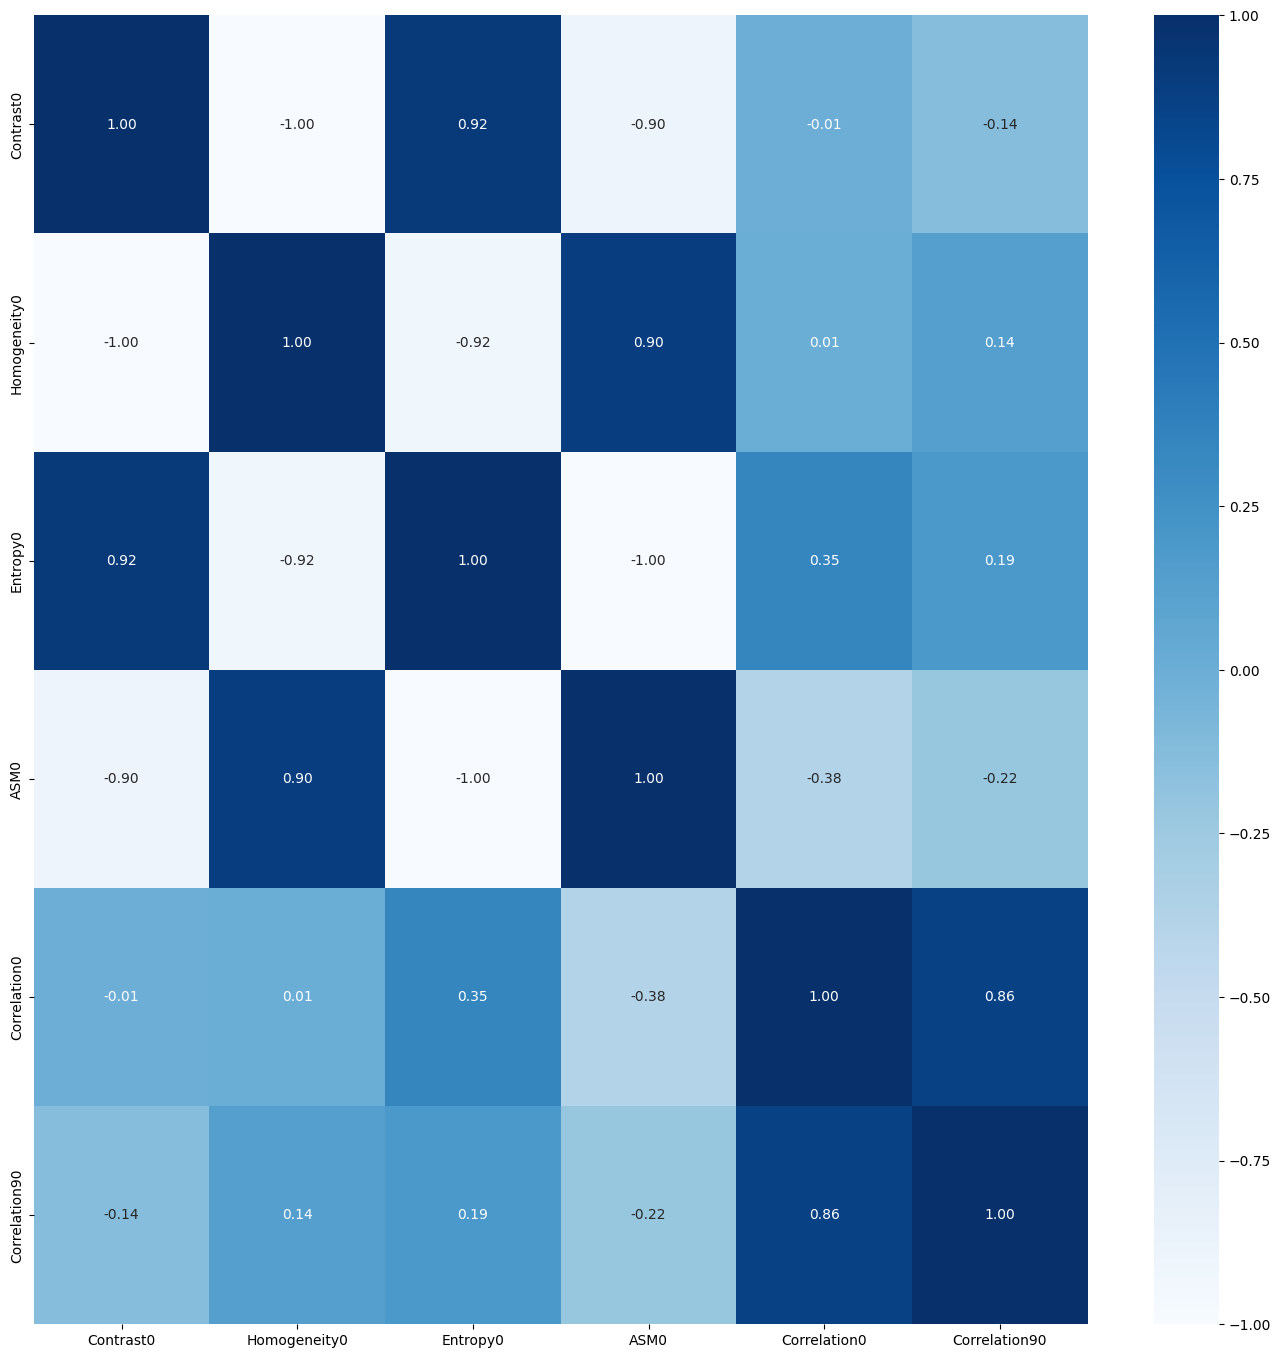

In [47]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


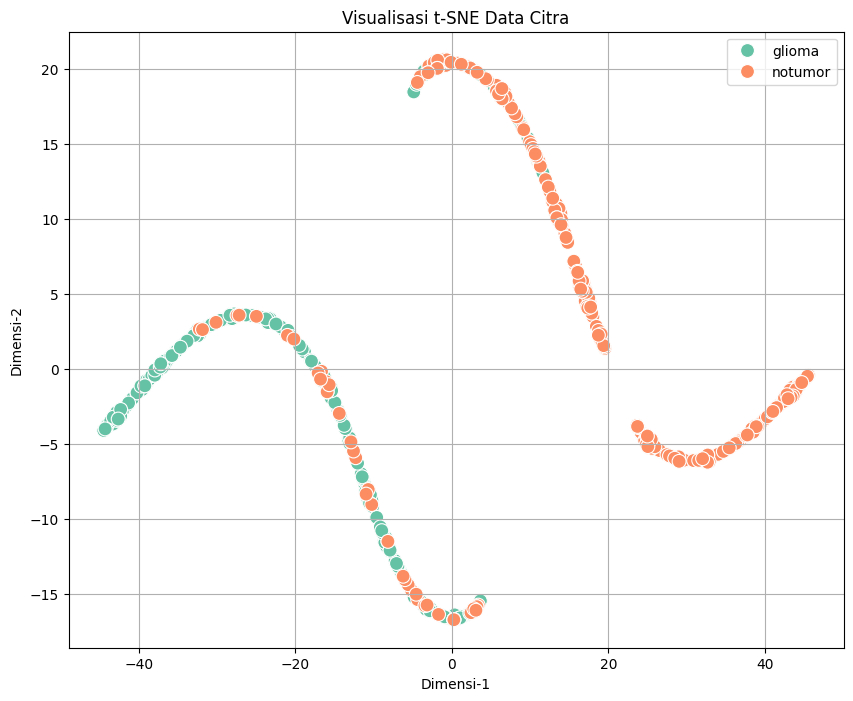

In [48]:
from sklearn.manifold import TSNE

# Jalankan t-SNE untuk reduksi ke 2 dimensi
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(x_new)

# Buat DataFrame hasil t-SNE
df_tsne = pd.DataFrame()
df_tsne['Dimensi-1'] = X_tsne[:, 0]
df_tsne['Dimensi-2'] = X_tsne[:, 1]
df_tsne['Label'] = y

# Plot dengan seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dimensi-1', y='Dimensi-2', hue='Label', data=df_tsne, palette='Set2', s=100
)
plt.title('Visualisasi t-SNE Data Citra')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [49]:

X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(480, 6)
(120, 6)
(480,)
(120,)


In [50]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [51]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [52]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       238
     notumor       0.99      0.99      0.99       242

    accuracy                           0.99       480
   macro avg       0.99      0.99      0.99       480
weighted avg       0.99      0.99      0.99       480

[[235   3]
 [  2 240]]
Accuracy: 0.9895833333333334

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.86      0.90      0.88        62
     notumor       0.89      0.84      0.87        58

    accuracy                           0.88       120
   macro avg       0.88      0.87      0.87       120
weighted avg       0.88      0.88      0.87       120

[[56  6]
 [ 9 49]]
Accuracy: 0.875


In [53]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.86      0.96      0.91       238
     notumor       0.95      0.85      0.90       242

    accuracy                           0.90       480
   macro avg       0.91      0.90      0.90       480
weighted avg       0.91      0.90      0.90       480

[[228  10]
 [ 36 206]]
Accuracy: 0.9041666666666667

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.85      0.94      0.89        62
     notumor       0.92      0.83      0.87        58

    accuracy                           0.88       120
   macro avg       0.89      0.88      0.88       120
weighted avg       0.89      0.88      0.88       120

[[58  4]
 [10 48]]
Accuracy: 0.8833333333333333


In [54]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.92      0.94      0.93       238
     notumor       0.94      0.92      0.93       242

    accuracy                           0.93       480
   macro avg       0.93      0.93      0.93       480
weighted avg       0.93      0.93      0.93       480

[[224  14]
 [ 19 223]]
Accuracy: 0.93125

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.85      0.94      0.89        62
     notumor       0.92      0.83      0.87        58

    accuracy                           0.88       120
   macro avg       0.89      0.88      0.88       120
weighted avg       0.89      0.88      0.88       120

[[58  4]
 [10 48]]
Accuracy: 0.8833333333333333


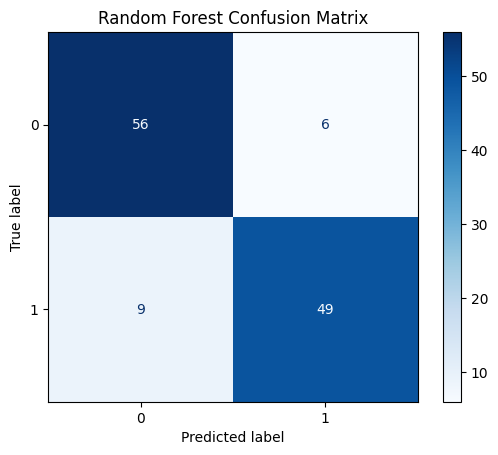

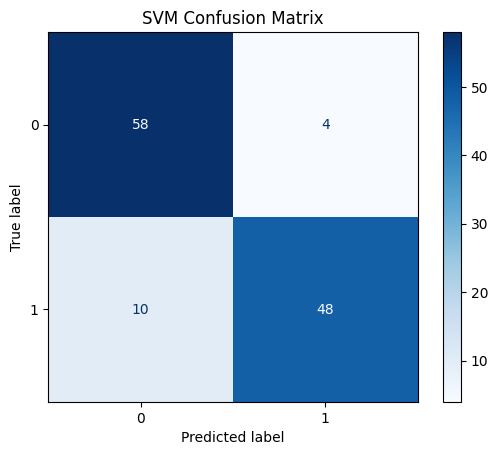

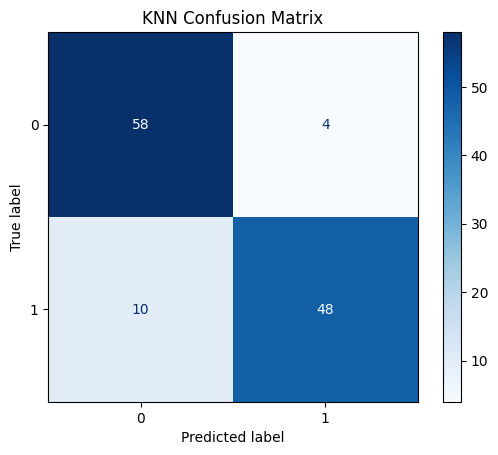

In [55]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")